# Challange - Create a router with LangGraph
Text processing application that can;
* revert a string
* convert a string to uppercase

The application;
* accepts user input and action type
* based on action routes to the appropriate node (reverse, or upper)
* handles invalid actions gracefully


In [54]:
from typing import TypedDict, Literal
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

## State Schema
* input: The user's input string
* action: The action to be performed
* output: The processed output

In [55]:
class State(TypedDict):
    input: str
    action: Literal["reverse", "upper"]
    output: str

    

In [66]:
workflow = StateGraph(State)

## Nodes

* Node A -> reverse the input
* Node B -> convert input to upper case

In [67]:
def node_a(state: State):
    print("Node A\n")
    output = state["input"][::-1]
    print(f"output: {output}")
    return {"output": output}

In [68]:
def node_b(state: State): 
    print("Node A\n")
    output = state["input"].upper()
    print(f"output: {output}")
    return {"output": output}

In [69]:
workflow.add_node("node_a", node_a)
workflow.add_node("node_b", node_b)

## Routing Function
Depending on the action it should return node_ad or node_b


In [70]:
def routing_function(state:State):
    action = state["action"]
    match action:
        case "reverse":
            return "node_a"
        case "upper":
            return "node_b"
        case _:
            raise ValueError(f"Provided action {action} is not valid. Please use either \'reversed\' or \'upper\'.")
    

## Edges

In [71]:
workflow.add_conditional_edges(
    source=START,
    path=routing_function,
    path_map=["node_a", "node_b"]
)

In [72]:
workflow.add_edge("node_a", END)
workflow.add_edge("node_b", END)

In [73]:
graph = workflow.compile()

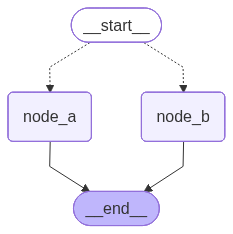

In [74]:
display(
    Image(
        graph.get_graph().draw_mermaid_png()
    )
)

In [75]:
graph.invoke(
    input = {
        "input": "This is some string",
        "action": "reverse"
    }
)

Node A

output: gnirts emos si sihT


{'input': 'This is some string',
 'action': 'reverse',
 'output': 'gnirts emos si sihT'}

In [76]:
graph.invoke(
    input = {
        "input": "This is some string",
        "action": "upper"
    }
)

Node A

output: THIS IS SOME STRING


{'input': 'This is some string',
 'action': 'upper',
 'output': 'THIS IS SOME STRING'}

In [77]:
try:
    graph.invoke(
        input = {
            "input": "This is some string",
            "action": "incorrect"
        }
    )
except ValueError as e:
    print(f"Error: {e}")

ValueError: Provided action incorrect is not valid. Please use either 'reversed' or 'upper'.